# Phase-Synthesis Stress Matrix

This benchmark exercises PennyLane's root-finding QSVT phase solver across increasing polynomial degree, shrinking boundedness margin, and a larger monomial-coefficient dynamic range. It records convergence, phase count, reconstruction error, and classical synthesis time in reproducible JSON and CSV artifacts.

## Variable definitions

- $P_j(x)$ is the polynomial for named stress case $j$ on the normalized domain $x\in[-1,1]$.
- $d$ (`degree`) is the highest nonzero monomial degree and `phase_count` is the number of synthesized QSVT projector phases.
- `boundedness_margin` is $1-\max_{x\in[-1,1]}|P_j(x)|$; a smaller positive value lies closer to the QSVT unit bound.
- `coefficient_dynamic_range` is the ratio between the largest and smallest nonzero monomial-coefficient magnitudes.
- `REPEATS` is the number of classical solver attempts per case and `SOLVERS` lists the selected phase solvers.
- `converged` means every repeated attempt succeeded; `max_reconstruction_error` compares the synthesized scalar phase sequence with $P_j$.
- `mean_time_seconds` measures Python wall-clock time for classical phase synthesis, not circuit or hardware runtime.


## Notebook guide

- **Learning objective:** stress phase synthesis across conditioning regimes.
- **Prerequisites:** an editable repository install and familiarity with classical baselines and QSVT resource proxies.
- **Estimated runtime:** about 3–5 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](06_encoding_aware_resources.ipynb).


## Truth contract

The measured component is classical phase synthesis and scalar reconstruction. No block encoding, QSVT circuit, state preparation, device execution, compilation, or hardware runtime is benchmarked. Only the base-install `root-finding` solver is used so the committed notebook remains reproducible across supported PennyLane environments; optional iterative solvers require additional dependency and compatibility qualification. Wall-clock values are environment-specific and must not be interpreted as asymptotic complexity.


In [1]:
import csv
import platform

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from notebooks._support import (
    benchmark_output_dirs,
    display_table,
    find_repo_root,
)
from qsvt.reports import save_report
from qsvt.synthesis import benchmark_phase_solver_stress_matrix


## Conditioning cases and solver policy

The matrix begins with a degree-one polynomial having margin $0.5$, then increases degree and moves closer to the unit bound. The scaled seventh Chebyshev polynomial is bounded by $0.95$ but has monomial coefficients spanning a factor of 16, separating coefficient conditioning from scalar boundedness. The degree-nine monomial keeps the same $0.05$ margin with a simple coefficient range.


In [2]:
CASES = {
    "linear-margin": [0.0, 0.5],
    "cubic-moderate": [0.0, 0.0, 0.0, 0.8],
    "scaled-chebyshev-7": [0.0, -6.65, 0.0, 53.2, 0.0, -106.4, 0.0, 60.8],
    "nonic-near-boundary": [0.0] * 9 + [0.95],
}
SOLVERS = ["root-finding"]
REPEATS = 2
RECONSTRUCTION_POINTS = 129

stress = benchmark_phase_solver_stress_matrix(
    CASES,
    solvers=SOLVERS,
    repeats=REPEATS,
    reconstruction_num_points=RECONSTRUCTION_POINTS,
)
stress_report = stress.as_report()
rows = stress_report["rows"]
display_table(
    "Phase-synthesis stress rows",
    rows,
    [
        ("case", lambda row: row["case"]),
        ("degree", lambda row: row["degree"]),
        ("coefficient range", lambda row: row["coefficient_dynamic_range"]),
        ("margin", lambda row: row["boundedness_margin"]),
        ("converged", lambda row: row["converged"]),
        ("phase count", lambda row: row["phase_count"]),
        ("max reconstruction error", lambda row: row["max_reconstruction_error"]),
        ("mean time (s)", lambda row: row["mean_time_seconds"]),
    ],
    layout="rows",
)


Phase-synthesis stress rows
---------------------------
case                 degree  coefficient range  margin  converged  phase count  max reconstruction error  mean time (s)
-------------------  ------  -----------------  ------  ---------  -----------  ------------------------  -------------
linear-margin        1       1                  0.5     True       2            5.00e-13                  0.001294     
cubic-moderate       3       1                  0.2     True       4            8.00e-13                  0.001423     
scaled-chebyshev-7   7       16                 0.05    True       8            9.52e-13                  0.00163      
nonic-near-boundary  9       1                  0.05    True       10           9.49e-13                  0.001792     


## Degree, margin, reconstruction, and timing

The phase count should follow $d+1$ for these definite-parity polynomials. Reconstruction error is plotted against the certified margin, while the final panel reports observed classical synthesis time. The timing panel is descriptive for this environment only; convergence and reconstruction are the portable numerical checks.


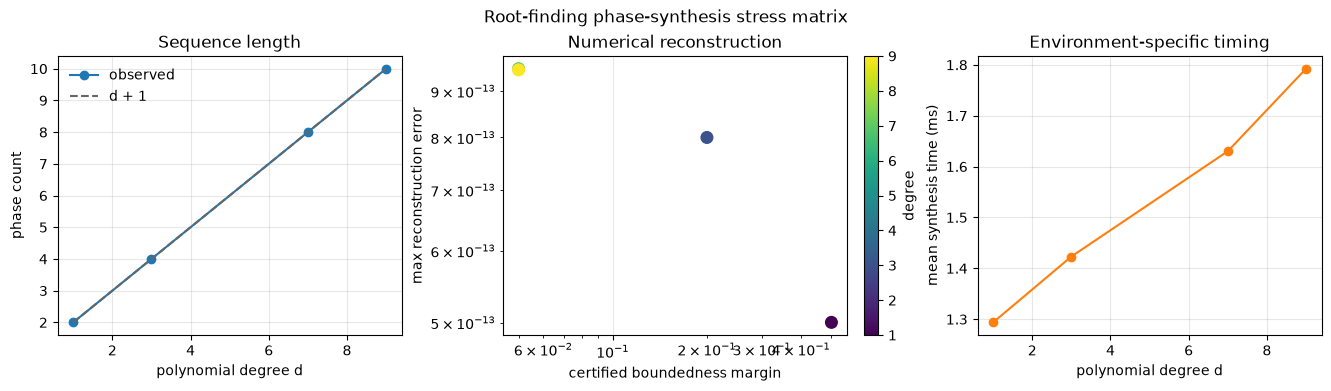

In [3]:
degrees = np.array([row["degree"] for row in rows])
phase_counts = np.array([row["phase_count"] for row in rows])
margins = np.array([row["boundedness_margin"] for row in rows])
reconstruction_errors = np.array([row["max_reconstruction_error"] for row in rows])
mean_times_ms = 1e3 * np.array([row["mean_time_seconds"] for row in rows])

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8), constrained_layout=True)
axes[0].plot(degrees, phase_counts, "o-", label="observed")
axes[0].plot(degrees, degrees + 1, "--", color="0.4", label="d + 1")
axes[0].set_xlabel("polynomial degree d")
axes[0].set_ylabel("phase count")
axes[0].set_title("Sequence length")
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.3)

scatter = axes[1].scatter(margins, reconstruction_errors, c=degrees, s=70, cmap="viridis")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("certified boundedness margin")
axes[1].set_ylabel("max reconstruction error")
axes[1].set_title("Numerical reconstruction")
fig.colorbar(scatter, ax=axes[1], label="degree")
axes[1].grid(alpha=0.3)

axes[2].plot(degrees, mean_times_ms, "o-", color="tab:orange")
axes[2].set_xlabel("polynomial degree d")
axes[2].set_ylabel("mean synthesis time (ms)")
axes[2].set_title("Environment-specific timing")
axes[2].grid(alpha=0.3)
fig.suptitle("Root-finding phase-synthesis stress matrix")
plt.show()


## Committed artifacts

The JSON artifact retains nested per-case reports, flat rows, conventions, truth boundaries, and the software environment. The CSV contains the flat stress matrix for release-to-release comparison. Timing values may change across machines even when convergence and reconstruction remain stable.


In [4]:
output_root, ARTIFACT_DIR, TABLE_DIR = benchmark_output_dirs()
repo_root = find_repo_root()
try:
    import tomllib
except ModuleNotFoundError:
    import tomli as tomllib
project = tomllib.loads((repo_root / "pyproject.toml").read_text(encoding="utf-8"))["project"]
payload = {
    **stress_report,
    "notebook": "notebooks/benchmarks/07_phase_synthesis_stress_matrix.ipynb",
    "solver_policy": {
        "selected_solvers": SOLVERS,
        "optional_iterative_solvers_excluded": True,
        "reason": "base-install reproducibility across supported PennyLane versions",
    },
    "environment": {
        "python": platform.python_version(),
        "qsvt_pennylane": project["version"],
        "pennylane": qml.__version__,
        "numpy": np.__version__,
    },
    "notebook_truth_contract": {
        "measured_component": "classical_phase_synthesis",
        "is_quantum_runtime_benchmark": False,
        "is_hardware_runtime_benchmark": False,
        "timing_is_environment_specific": True,
        "portable_checks": ["convergence", "phase_count", "reconstruction_error"],
    },
}
json_path = save_report(payload, ARTIFACT_DIR / "phase_synthesis_stress_matrix.json")
csv_path = TABLE_DIR / "phase_synthesis_stress_summary.csv"
with csv_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)
json_display = json_path.relative_to(repo_root) if json_path.is_relative_to(repo_root) else json_path
csv_display = csv_path.relative_to(repo_root) if csv_path.is_relative_to(repo_root) else csv_path
print(f"wrote {json_display}")
print(f"wrote {csv_display}")


wrote results/benchmarks/phase_synthesis_stress_matrix.json
wrote results/tables/phase_synthesis_stress_summary.csv


## Validation

These checks protect the case matrix, solver policy, repeated convergence, expected phase-count relation, coefficient-range stress, reconstruction accuracy, and committed artifact paths. They deliberately avoid fixed wall-clock thresholds.


In [5]:
assert len(rows) == len(CASES) * len(SOLVERS)
assert stress_report["summary"]["all_converged"]
assert all(row["attempts"] == REPEATS for row in rows)
assert all(row["successes"] == REPEATS for row in rows)
assert all(row["phase_count"] == row["degree"] + 1 for row in rows)
assert max(row["coefficient_dynamic_range"] for row in rows) >= 16.0
assert min(row["boundedness_margin"] for row in rows) > 0.0
assert max(row["max_reconstruction_error"] for row in rows) < 1e-9
assert json_path.exists() and csv_path.exists()
print("validation: passed")


validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to stress phase synthesis across conditioning regimes.
- **Interpretation boundary:** Environment-specific timings and logical proxies are evidence for different claims and are not quantum runtime measurements.
- **Continue:** [collection index](README.md) · [previous](06_encoding_aware_resources.ipynb).
